In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, '../')

from FL_code.prior_calculator import PriorCalculator
from FL_code.cancer_quantizer import WZQuantizerCancer
from FL_code.run_fl import FLConfig
from FL_code.models import initialize_model
from FL_code.utils import StateDictManager
from FL_code.cancer_protocol import CancerConfig


data_dir = '../data/training_grads'
all_x_data = [torch.load(os.path.join(data_dir, f)) for f in os.listdir(data_dir) if f.endswith('.pt')]
all_x_data = torch.concat(all_x_data, dim=0)

sdm = StateDictManager(initialize_model(FLConfig(), torch.device(f"cuda")))
vec_slices = []
offset = 0
for temp in sdm.numels:
    vec_slices.append(slice(offset, offset + temp))
    offset += temp
for temp in sdm.numels:
    vec_slices.append(slice(offset, offset + temp))
    offset += temp

In [2]:
num_planes, bins_per_plane = 3, 8
outlier_threshold = 1.5

quantizer = WZQuantizerCancer(
    CancerConfig(reconst_ld=200), FLConfig(),
    num_planes, bins_per_plane, si_size=0, norm_slices=vec_slices, outlier_threshold = outlier_threshold)

quantizer.coding_model.load_state_dict(
    torch.load('../data/pre_trained_pth/bpp8_np3_pretrained_wzq_rnn.pth'))


<All keys matched successfully>

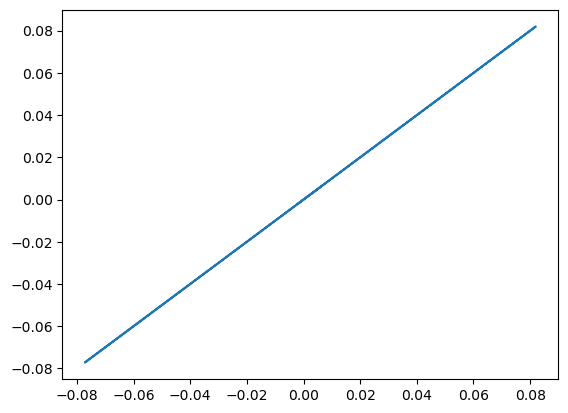

In [3]:
all_x_data_preprocessed, norm_fact, out_fact = quantizer._apply_pre_process(all_x_data)
all_x_data_recovered = quantizer._post_process(all_x_data_preprocessed, norm_fact, out_fact)

plt.plot(all_x_data, all_x_data_recovered)
plt.show()

In [ ]:
payload = quantizer.encoding_process(all_x_data)
recons = quantizer.decoding_process(payload)

In [ ]:
np.array([0,1,0,1], dtype=bool).nbytes